## Colab 환경에서 실행 시 환경 설정

In [ ]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
# %cd drive/MyDrive/'Colab Notebooks'

%cd drive/MyDrive/Colab/20250509

#### 코랩에서 한국어 표시하기

In [ ]:
!pip install koreanize-matplotlib

In [ ]:
import koreanize_matplotlib

# 🔖 자연어 처리

<a id="lecture_index"></a>
## 수업 목차 


[1. Attention](#five)<br>
- 개발 배경
- Attention Mechanism의 특징
- Attention 구조 시각화 및 수식


## <a id='one'>1️⃣ Attention</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## Attention

> ⭐️ 어떤 단어를 주목할지를 학습할 수 있게 하는 연산 (메커니즘) ⭐️ <br>
> Attention은 디코더가 인코더의 출력 전체를 가중합하여, 현재 시점에 가장 관련 있는 정보를 선택적으로 집중하도록 하는 메커니즘 <br>

## 개발 배경 
> 💡 Encoder-Decoder 계열의 기계 번역 모델의 한계를 극복하기 위해 만들어짐 

### 🚫 성능 향상의 걸림돌 
#### 👉  "고정된 크기의 Context Vector"  <br>
#### 👉  "순차 처리를 하는 RNN 계열의 인코더"

### Side Effect

#### 1️⃣ 정보 손실 문제 
-> 길이가 짧은 문장도, 긴 문장도 같은 길이의 벡터로 변환 해야 하기 때문에 긴 문장을 요약할때는 정보 손실이 발생 

#### 2️⃣ 중요한 부분을 강조하지 못함 
-> 입력 문장을 압축한 벡터 하나만을 참조하기 때문에, 지금 생성할 단어가 입력의 어떤 부분과 연관이 있는지 알 수 없음

#### 3️⃣ 병렬 처리 불가 
-> RNN 계열 인코더가 입력을 순차적으로 처리해야 하기 때문에, 학습 및 추론 과정에서 병렬 처리가 어렵고 속도가 느림


## ✅ Attention Mechanism의 특징

#### ① 입력 시퀀스에서 필요한 정보만 동적으로 선택 
#### ② 학습 가능성 
- score 계산 시 가중치를 사용하기 때문에 end to end로 학습이 가능
#### ③ 해석 가능성 
- attention weight은 어느 곳을 참고하여 만들어 졌는가를 시각화 할 수 있기 때문에 해석 가능 
#### ④ 정보 손실 방지
- 긴 문장에서도 정보 손실이 적고, 문맥을 유연하게 학습할 수 있음
#### ⑤ 양방향 문맥 반영 
- 입력 시퀀스의 이전 단어와 이후 단어의 정보를 모두 활용해 인코딩함. 따라서 앞 뒤 문맥을 이해할 수 있는 구조 
- ⚠️ 단, Attention 매커니즘과 양방향 RNN의 조합이 필수인건 아님 

## Attention 구조 시각화 및 수식

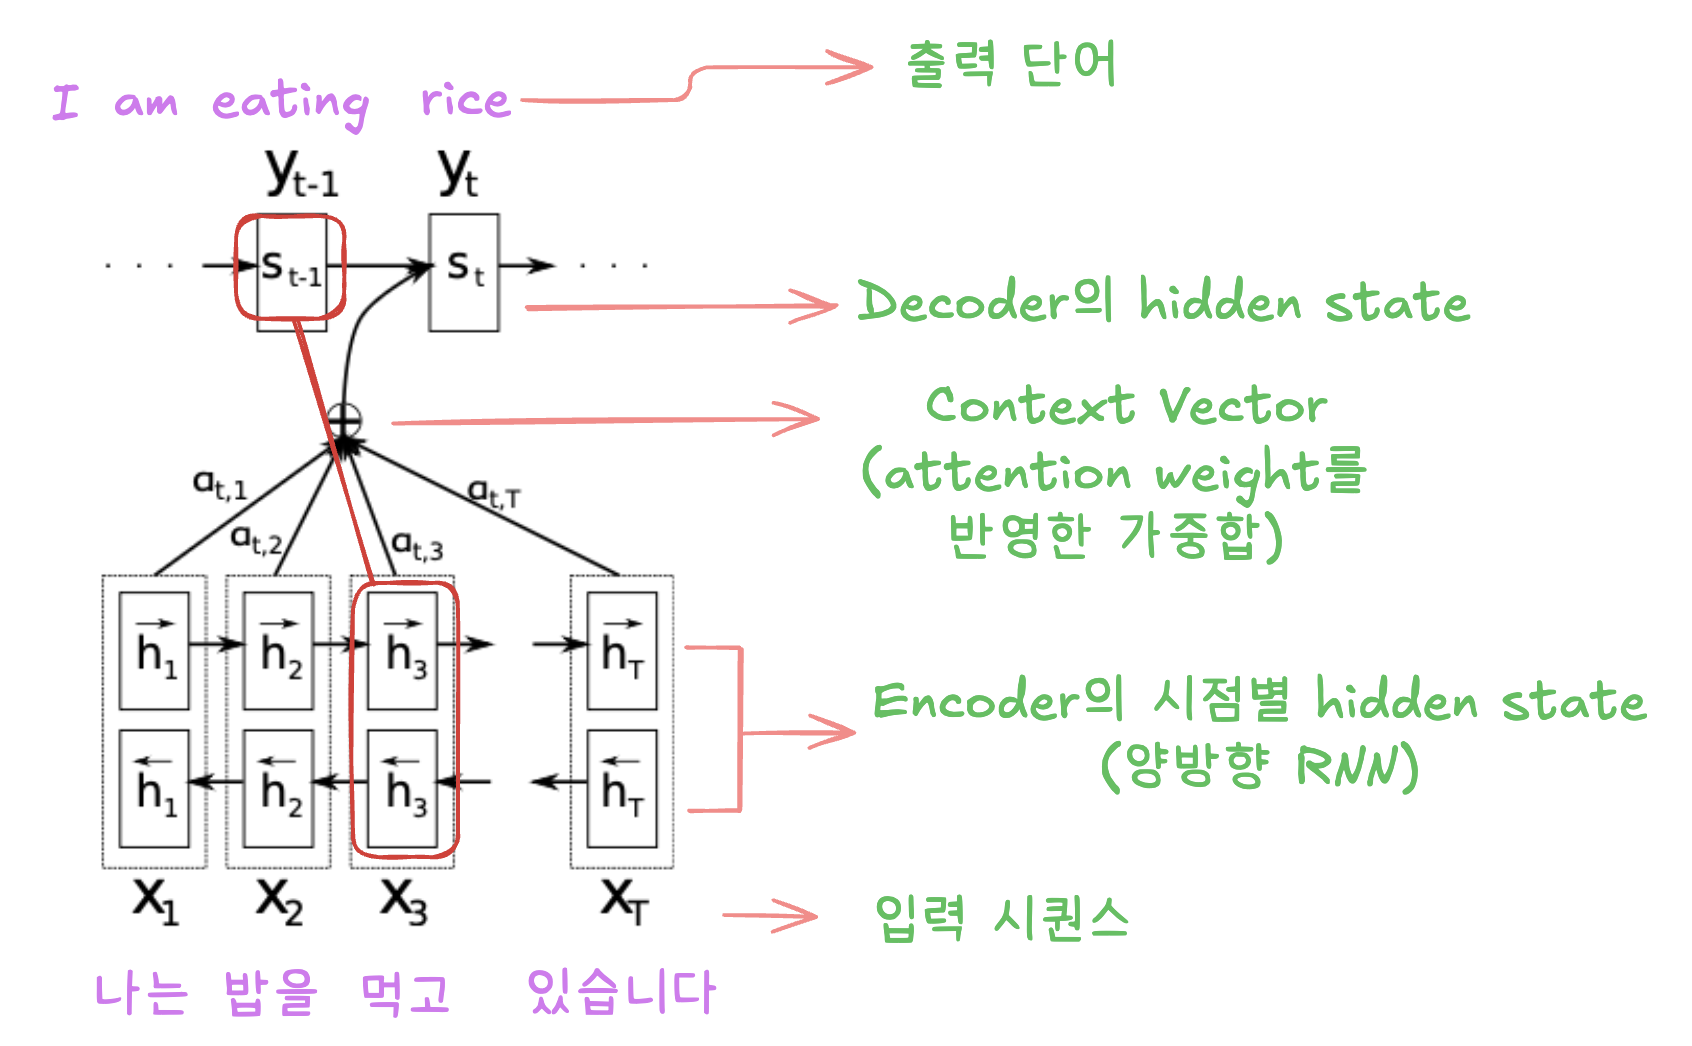

**1. Context vector 계산**
$$
\mathbf{c}_i = \sum_{j=1}^{Tx} \alpha_{i,j} \cdot \mathbf{h}_j
$$

ci: 디코더가 i번째 단어를 생성할 때 참고할 context vector <br>
Tx: 입력 시퀀스의 길이 <br>
αij: 디코더의 시점 i에서, 인코더 시점 j에 주는 attention 가중치 <br>
hj: 인코더의 j번째 hidden state (BiRNN or BiLSTM의 output) <br>

**2. Attention weights (softmax)**
$$
\alpha_{i,j} = \frac{\exp(e_{i,j})}{\sum_{k=1}^{Tx} \exp(e_{i,k})}
$$

eij: decoder의 i번째 상태와 encoder의 j번째 상태간의 유사도 혹은 두 상태간의 의미적 연관성을 정량적으로 표현한 값 <br>
αij: attention 가중치. 이 가중치 값은 유사도 값을 확률처럼 정규화 함. (전체 가중치 값의 합이 1이 되도록)

**3. Alignment score 계산**
$$
e_{i, j} = \mathbf{v}^\top \tanh\left( \mathbf{W}_h \mathbf{h}_j + \mathbf{W}_s \mathbf{s}_{i-1} \right)
$$

si-1: decoder의 이전 hidden state (지금까지 생성한 단어들의 문맥 요약 정보) <br>
hj: encoder의 j번째 hidden state (source 문장에서 j번째 단어 주변 문맥 정보) <br>
Ws * Si-1 + Wh * hj: 두 상태를 각각 선형 변환해서 같은 공간으로 맞춘 후 더함 <br>
tanh: 두 상태 벡터의 관계를 잘 표현할 수 있도록 비선형적 변환을 하는 역할 <br>
VT: decoder-encoder 관계 표현을 한 방향으로 projection 하여 하나의 점수로 만드는 역할 <br> 

✅ alignment의 의미: 두 상태가 의미적으로 잘 맞물렸는가 <br>
✅ 위 방식으로 점수를 내는 방식을 Bahdanau attention 혹은 Additive attention이라고 부름

### 짚고 넘어가기

| Attention 기호 | 연산 종류             | 의미       | 수식                                                                 | 코드                         |
|----------------------|----------------------|------------|----------------------------------------------------------------------|------------------------------|
|Luong-style <br> Si-1 * hj| 벡터와 벡터의 dot product | 닮은 정도 | a · b = a₁b₁ + a₂b₂ + ... + aₙbₙ  | `np.dot(a, b)` 또는 `a @ b` |
|Bahdanau <br> Ws * Si-1, Wh * hj| 벡터와 행렬의 행렬곱 | 선형 변환 <br> 행렬: 가중치, 열벡터: 입력 시퀀스 | 행렬(A) x 열벡터(x) | `np.dot(A, x)` 또는 `A @ x` |

### Seq2Seq의 Decoder vs Seq2Seq + Attention의 Decoder

#### ✅ 공통점: Encoder에서 만든 문맥 벡터를 참고하고, 지금까지의 출력 단어의 흐름과 바로 전에 생성한 토큰을 기반으로 다음 토큰을 예측 하는 역할  <br>
#### 🎯 차이점: Attention을 적용한 문맥 벡터는 weighted sum 연산을 한 문맥 벡터를 참고한다. 이때 이 문맥 벡터는 입력 시퀀스의 매 시점과 지금까지 생성한 출력 시퀀스와의 연관성 정보를 포함하고 있다

### 미리 알아둬야 할 연산

1. batch-wise matrix multiplication (배치 행렬 곱)
- 3차원 텐서들끼리 한 번에 여러 개의 행렬 곱
- (B, M, N) @ (B, N, P) -> (B, M, P)
2. repeat
- 지정한 차원만큼 반복해서 복제하는 연산

### PyTorch로 구현하기 